# GASP Sensitivity Analysis

This notebook provides a comprehensive sensitivity analysis for GASP (Generation of Arbitrary Spectral Profiles),
focusing on the relationship between trained flip angle (α) and T2/T1 ratios.

## Key Analyses:
1. **Training α vs Evaluation T2/T1 Ratio Heatmaps** - How flip angle affects performance across tissues
2. **Method Comparison** - Comparing linear, affine, quad, quad-cross methods
3. **Profile Comparison** - Different spectral profiles (Gaussian, Square, Bandpass)
4. **Training T2/T1 vs Evaluation T2/T1** - Cross-tissue generalization at fixed α
5. **Optimal Parameter Identification** - Finding best α for each tissue type

In [1]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, ticker
import warnings
warnings.filterwarnings('ignore')

# GASP imports
from gasp import responses, sampling
from gasp.gasp import train_gasp, run_gasp
from gasp.simulation import SSFPParams, simulate_ssfp_simple

# Set default plot style
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("GASP Sensitivity Analysis Notebook loaded successfully!")

GASP Sensitivity Analysis Notebook loaded successfully!


## Configuration Parameters

In [2]:
# Simulation parameters
WIDTH = 256
HEIGHT = 1
NPCS = 16
TRS_BASE = [5e-3, 10e-3, 20e-3]
GRADIENT = 2 * np.pi

# Sensitivity analysis grid
N_ALPHA = 50        # Number of flip angle values
N_RATIO = 50        # Number of T2/T1 ratio values
ALPHA_MIN = 5       # Minimum flip angle (degrees)
ALPHA_MAX = 90      # Maximum flip angle (degrees)
RATIO_MIN = 0.5     # Minimum T1/T2 ratio
RATIO_MAX = 20      # Maximum T1/T2 ratio

# Design matrix methods
METHODS = ['linear', 'affine', 'quad', 'quad-cross']

# Reference tissue types with their T1/T2 ratios
TISSUE_TYPES = {
    'Water': {'T1': 4.0, 'T2': 2.0, 'ratio': 2.0},
    'Fat': {'T1': 0.25, 'T2': 0.07, 'ratio': 3.57},
    'White Matter': {'T1': 0.6, 'T2': 0.08, 'ratio': 7.5},
    'Gray Matter': {'T1': 0.9, 'T2': 0.1, 'ratio': 9.0},
    'Liver': {'T1': 0.5, 'T2': 0.04, 'ratio': 12.5},
    'Muscle': {'T1': 0.9, 'T2': 0.05, 'ratio': 18.0},
    'Tendon': {'T1': 0.4, 'T2': 0.005, 'ratio': 80.0},
}

print(f"Grid size: {N_ALPHA} alphas x {N_RATIO} ratios = {N_ALPHA * N_RATIO} simulations per analysis")

Grid size: 50 alphas x 50 ratios = 2500 simulations per analysis


## Helper Functions

In [3]:
def sensitivity_analysis_alpha_vs_ratio(
    D, 
    T1_train=0.9, 
    T2_train=0.05, 
    alpha_min=5, 
    alpha_max=90, 
    n_alpha=50,
    ratio_min=0.5, 
    ratio_max=20, 
    n_ratio=50,
    method='affine',
    useL2=True,
    lam=1e-2
):
    """
    Perform sensitivity analysis: Train α vs Evaluation T1/T2 ratio.
    
    For each flip angle α:
      1. Train GASP coefficients on fixed tissue (T1_train, T2_train)
      2. Evaluate on varying T1/T2 ratios
    
    Returns:
        rmse_2d: (n_alpha, n_ratio) RMSE matrix
        rmse_1d: (n_alpha,) mean RMSE across ratios
        alphas: flip angle array (radians)
        ratios: T1/T2 ratio array
    """
    n_points = NPCS * len(TRS_BASE)
    TRs, PCs = sampling.grid_TR_sampling(n_points=n_points, TRs=TRS_BASE)
    
    # Get number of coefficients for method
    if method == 'linear':
        n_coeffs = n_points
    elif method == 'affine':
        n_coeffs = n_points + 1
    elif method == 'quad':
        n_coeffs = 2 * n_points + 1
    else:  # quad-cross
        n_coeffs = 2 * n_points + 1 + (n_points * (n_points - 1)) // 2
    
    alphas = np.deg2rad(np.linspace(alpha_min, alpha_max, n_alpha))
    ratios = np.linspace(ratio_min, ratio_max, n_ratio)
    T2_base = 0.1  # Fixed T2 for evaluation
    
    # Train coefficients for each alpha
    A = np.zeros((n_alpha, n_coeffs), dtype=np.complex128)
    for i, alpha in enumerate(alphas):
        params = SSFPParams(n_points, alpha, TRs, PCs)
        M = simulate_ssfp_simple(
            width=WIDTH, height=HEIGHT, 
            T1=T1_train, T2=T2_train,
            params=params, 
            minTR=np.min(TRs), 
            gradient=GRADIENT
        )
        _, An = train_gasp(M, D, method=method, useL2=useL2, lam=lam)
        A[i, :] = np.array(An)
    
    # Evaluate for each (alpha, ratio) combination
    rmse_2d = np.zeros((n_alpha, n_ratio))
    for i, alpha in enumerate(alphas):
        params = SSFPParams(n_points, alpha, TRs, PCs)
        for j, ratio in enumerate(ratios):
            T1_eval = T2_base * ratio
            M = simulate_ssfp_simple(
                width=WIDTH, height=HEIGHT,
                T1=T1_eval, T2=T2_base,
                params=params,
                minTR=np.min(TRs),
                gradient=GRADIENT
            )
            I = run_gasp(M, A[i, :], method=method)
            rmse_2d[i, j] = np.sqrt(np.mean((np.abs(I) - D)**2))
    
    rmse_1d = rmse_2d.mean(axis=1)
    
    return rmse_2d, rmse_1d, alphas, ratios


def sensitivity_analysis_ratio_vs_ratio(
    D,
    alpha=20,
    ratio_min=0.5,
    ratio_max=20,
    n_ratio=50,
    method='affine',
    useL2=True,
    lam=1e-2
):
    """
    Perform sensitivity analysis: Train T1/T2 ratio vs Evaluation T1/T2 ratio.
    
    At fixed flip angle, train on each ratio and evaluate on all ratios.
    
    Returns:
        rmse_2d: (n_ratio, n_ratio) RMSE matrix
        ratios: T1/T2 ratio array
    """
    n_points = NPCS * len(TRS_BASE)
    TRs, PCs = sampling.grid_TR_sampling(n_points=n_points, TRs=TRS_BASE)
    alpha_rad = np.deg2rad(alpha)
    
    # Get number of coefficients
    if method == 'linear':
        n_coeffs = n_points
    elif method == 'affine':
        n_coeffs = n_points + 1
    elif method == 'quad':
        n_coeffs = 2 * n_points + 1
    else:  # quad-cross
        n_coeffs = 2 * n_points + 1 + (n_points * (n_points - 1)) // 2
    
    ratios = np.linspace(ratio_min, ratio_max, n_ratio)
    T2_base = 0.1
    
    # Train coefficients for each ratio
    A = np.zeros((n_ratio, n_coeffs), dtype=np.complex128)
    params = SSFPParams(n_points, alpha_rad, TRs, PCs)
    
    for i, ratio in enumerate(ratios):
        T1_train = T2_base * ratio
        M = simulate_ssfp_simple(
            width=WIDTH, height=HEIGHT,
            T1=T1_train, T2=T2_base,
            params=params,
            minTR=np.min(TRs),
            gradient=GRADIENT
        )
        _, An = train_gasp(M, D, method=method, useL2=useL2, lam=lam)
        A[i, :] = np.array(An)
    
    # Evaluate for each (train_ratio, eval_ratio) combination
    rmse_2d = np.zeros((n_ratio, n_ratio))
    for i, train_ratio in enumerate(ratios):
        for j, eval_ratio in enumerate(ratios):
            T1_eval = T2_base * eval_ratio
            M = simulate_ssfp_simple(
                width=WIDTH, height=HEIGHT,
                T1=T1_eval, T2=T2_base,
                params=params,
                minTR=np.min(TRs),
                gradient=GRADIENT
            )
            I = run_gasp(M, A[i, :], method=method)
            rmse_2d[i, j] = np.sqrt(np.mean((np.abs(I) - D)**2))
    
    return rmse_2d, ratios


print("Helper functions defined.")

Helper functions defined.


## Plotting Functions

In [4]:
def plot_heatmap_alpha_vs_ratio(
    rmse_2d, alphas, ratios, 
    title='', 
    cmap='viridis_r',
    use_log=True,
    ax=None,
    show_tissue_lines=True
):
    """
    Plot heatmap of trained α vs T1/T2 ratio.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    
    alphas_deg = np.rad2deg(alphas)
    X, Y = np.meshgrid(ratios, alphas_deg)
    
    if use_log:
        # Use log scale for better visualization
        levels = np.logspace(np.log10(rmse_2d.min() + 1e-6), np.log10(rmse_2d.max()), 20)
        cs = ax.contourf(X, Y, rmse_2d, levels=levels, locator=ticker.LogLocator(), cmap=cmap)
    else:
        cs = ax.contourf(X, Y, rmse_2d, levels=20, cmap=cmap)
    
    cbar = plt.colorbar(cs, ax=ax, label='RMSE')
    
    # Add tissue reference lines
    if show_tissue_lines:
        for name, props in TISSUE_TYPES.items():
            if props['ratio'] >= ratios.min() and props['ratio'] <= ratios.max():
                ax.axvline(props['ratio'], color='white', linestyle='--', alpha=0.7, linewidth=1)
                ax.text(props['ratio'] + 0.2, alphas_deg.max() - 3, name, 
                       color='white', fontsize=8, rotation=90, va='top')
    
    ax.set_xlabel('T1/T2 Ratio (Evaluation)', fontsize=12)
    ax.set_ylabel('Flip Angle α (Training, degrees)', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    return ax


def plot_heatmap_ratio_vs_ratio(
    rmse_2d, ratios,
    title='',
    cmap='viridis_r',
    use_log=True,
    ax=None
):
    """
    Plot heatmap of training T1/T2 ratio vs evaluation T1/T2 ratio.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    X, Y = np.meshgrid(ratios, ratios)
    
    if use_log:
        levels = np.logspace(np.log10(rmse_2d.min() + 1e-6), np.log10(rmse_2d.max()), 20)
        cs = ax.contourf(X, Y, rmse_2d, levels=levels, locator=ticker.LogLocator(), cmap=cmap)
    else:
        cs = ax.contourf(X, Y, rmse_2d, levels=20, cmap=cmap)
    
    plt.colorbar(cs, ax=ax, label='RMSE')
    
    # Add diagonal line (train == eval)
    ax.plot([ratios.min(), ratios.max()], [ratios.min(), ratios.max()], 
            'w--', linewidth=2, label='Train = Eval')
    
    ax.set_xlabel('T1/T2 Ratio (Evaluation)', fontsize=12)
    ax.set_ylabel('T1/T2 Ratio (Training)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper left')
    
    return ax


print("Plotting functions defined.")

Plotting functions defined.


---
## 1. Training α vs Evaluation T1/T2 Ratio Heatmaps

This analysis shows how the flip angle used during GASP training affects performance when evaluated on tissues with different T1/T2 ratios.

In [5]:
# Define target profiles to analyze
D_gaussian = responses.gaussian(WIDTH, bw=0.2, shift=0)
D_square = responses.square(WIDTH, bw=0.2, shift=0)
D_bandpass = responses.bandpass(WIDTH, bw=0.25, shift=0, type='butterworth')

print("Target profiles created.")

Target profiles created.


### 1.1 Gaussian Profile - Method Comparison

In [6]:
# Run sensitivity analysis for all methods with Gaussian profile
# Training on muscle tissue (T1=0.9, T2=0.05)

results_gaussian = {}

print("Running sensitivity analysis for Gaussian profile...")
for method in METHODS:
    print(f"  Processing {method}...")
    rmse_2d, rmse_1d, alphas, ratios = sensitivity_analysis_alpha_vs_ratio(
        D_gaussian,
        T1_train=0.9, T2_train=0.05,  # Muscle tissue
        alpha_min=ALPHA_MIN, alpha_max=ALPHA_MAX, n_alpha=N_ALPHA,
        ratio_min=RATIO_MIN, ratio_max=RATIO_MAX, n_ratio=N_RATIO,
        method=method,
        useL2=True, lam=1e-2
    )
    results_gaussian[method] = {
        'rmse_2d': rmse_2d,
        'rmse_1d': rmse_1d,
        'alphas': alphas,
        'ratios': ratios
    }

print("Done!")

Running sensitivity analysis for Gaussian profile...
  Processing linear...
  Processing affine...
  Processing quad...
  Processing quad-cross...
Done!


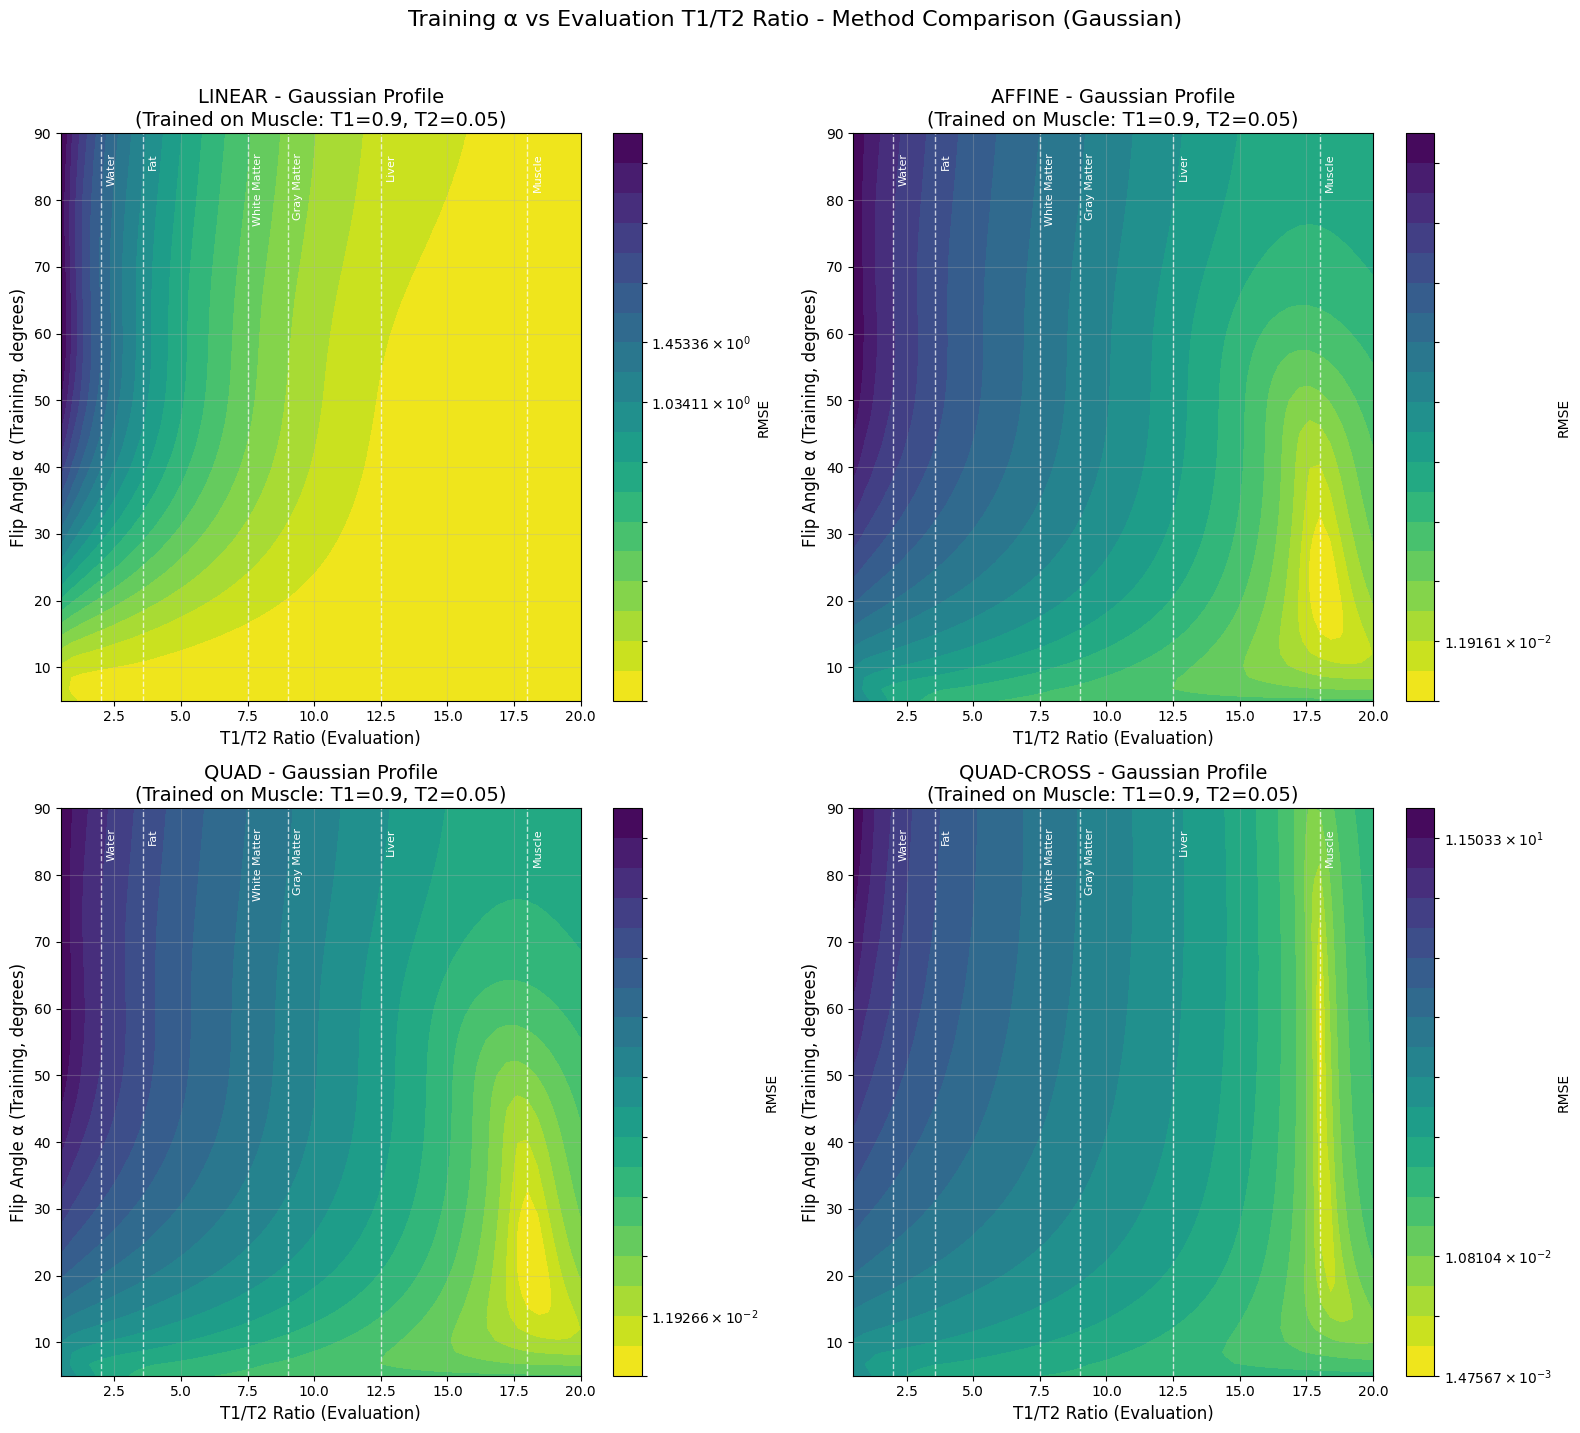

In [7]:
# Plot heatmaps for all methods
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, method in enumerate(METHODS):
    res = results_gaussian[method]
    plot_heatmap_alpha_vs_ratio(
        res['rmse_2d'], res['alphas'], res['ratios'],
        title=f'{method.upper()} - Gaussian Profile\n(Trained on Muscle: T1=0.9, T2=0.05)',
        ax=axes[idx],
        cmap='viridis_r'
    )

plt.suptitle('Training α vs Evaluation T1/T2 Ratio - Method Comparison (Gaussian)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 1.2 Profile Comparison (Affine Method)

In [8]:
# Compare different profiles using affine method
profiles = {
    'Gaussian': D_gaussian,
    'Square': D_square,
    'Butterworth': D_bandpass
}

results_profiles = {}

print("Running sensitivity analysis for different profiles...")
for name, D in profiles.items():
    print(f"  Processing {name}...")
    rmse_2d, rmse_1d, alphas, ratios = sensitivity_analysis_alpha_vs_ratio(
        D,
        T1_train=0.9, T2_train=0.05,
        alpha_min=ALPHA_MIN, alpha_max=ALPHA_MAX, n_alpha=N_ALPHA,
        ratio_min=RATIO_MIN, ratio_max=RATIO_MAX, n_ratio=N_RATIO,
        method='affine',
        useL2=True, lam=1e-2
    )
    results_profiles[name] = {
        'rmse_2d': rmse_2d,
        'rmse_1d': rmse_1d,
        'alphas': alphas,
        'ratios': ratios
    }

print("Done!")

Running sensitivity analysis for different profiles...
  Processing Gaussian...
  Processing Square...
  Processing Butterworth...
Done!


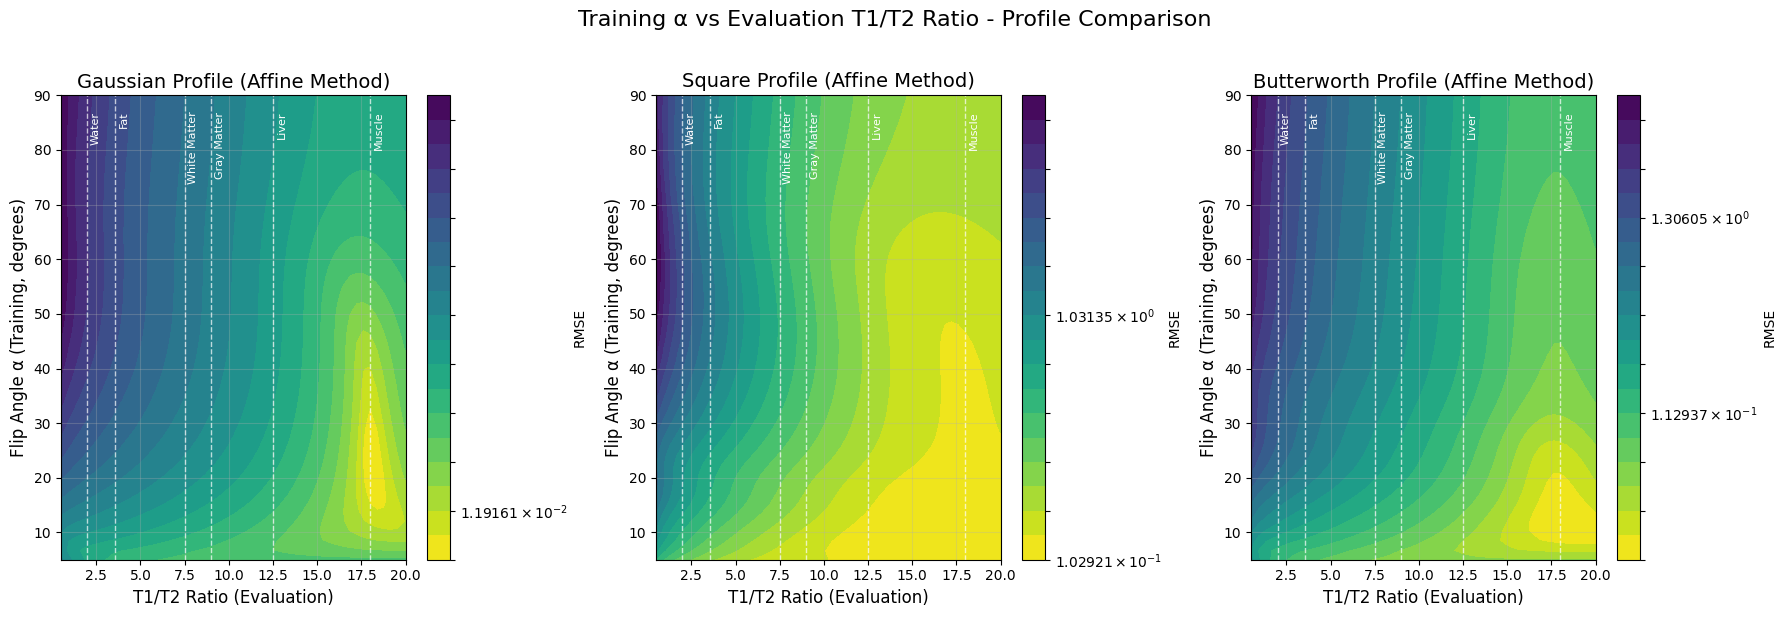

In [9]:
# Plot heatmaps for all profiles
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, res) in enumerate(results_profiles.items()):
    plot_heatmap_alpha_vs_ratio(
        res['rmse_2d'], res['alphas'], res['ratios'],
        title=f'{name} Profile (Affine Method)',
        ax=axes[idx],
        cmap='viridis_r'
    )

plt.suptitle('Training α vs Evaluation T1/T2 Ratio - Profile Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 1.3 Optimal Flip Angle Analysis


Optimal Flip Angles for Gaussian Profile:
--------------------------------------------------
Method          Optimal α       Min RMSE       
--------------------------------------------------
linear          5.0             0.1960         
affine          6.7             0.0495         
quad            6.7             0.0496         
quad-cross      6.7             0.0523         


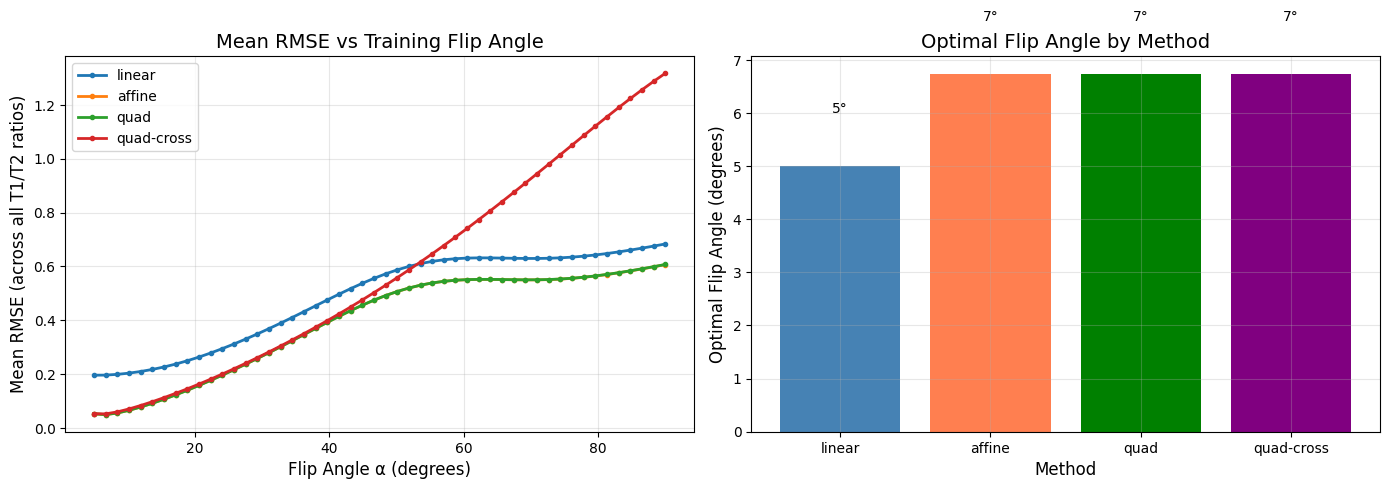

In [10]:
# Find optimal flip angle for each method (minimizing mean RMSE across ratios)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean RMSE vs Alpha for each method
for method in METHODS:
    res = results_gaussian[method]
    alphas_deg = np.rad2deg(res['alphas'])
    axes[0].plot(alphas_deg, res['rmse_1d'], 'o-', label=method, linewidth=2, markersize=3)

axes[0].set_xlabel('Flip Angle α (degrees)', fontsize=12)
axes[0].set_ylabel('Mean RMSE (across all T1/T2 ratios)', fontsize=12)
axes[0].set_title('Mean RMSE vs Training Flip Angle', fontsize=14)
axes[0].legend()

# Optimal alpha table
print("\nOptimal Flip Angles for Gaussian Profile:")
print("-" * 50)
print(f"{'Method':<15} {'Optimal α':<15} {'Min RMSE':<15}")
print("-" * 50)

optimal_data = []
for method in METHODS:
    res = results_gaussian[method]
    opt_idx = np.argmin(res['rmse_1d'])
    opt_alpha = np.rad2deg(res['alphas'][opt_idx])
    min_rmse = res['rmse_1d'][opt_idx]
    print(f"{method:<15} {opt_alpha:<15.1f} {min_rmse:<15.4f}")
    optimal_data.append((method, opt_alpha, min_rmse))

# Bar chart of optimal alphas
methods_labels = [d[0] for d in optimal_data]
optimal_alphas = [d[1] for d in optimal_data]
axes[1].bar(methods_labels, optimal_alphas, color=['steelblue', 'coral', 'green', 'purple'])
axes[1].set_xlabel('Method', fontsize=12)
axes[1].set_ylabel('Optimal Flip Angle (degrees)', fontsize=12)
axes[1].set_title('Optimal Flip Angle by Method', fontsize=14)

for i, (method, alpha, rmse) in enumerate(optimal_data):
    axes[1].text(i, alpha + 1, f'{alpha:.0f}°', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 2. Training T1/T2 vs Evaluation T1/T2 Ratio (Cross-Tissue Generalization)

This analysis shows how well GASP coefficients trained on one T1/T2 ratio generalize to different ratios.

In [11]:
# Run cross-tissue generalization analysis at different flip angles
test_alphas = [10, 20, 45, 60]

results_cross_tissue = {}

print("Running cross-tissue generalization analysis...")
for alpha in test_alphas:
    print(f"  Processing α = {alpha}°...")
    rmse_2d, ratios = sensitivity_analysis_ratio_vs_ratio(
        D_gaussian,
        alpha=alpha,
        ratio_min=RATIO_MIN, ratio_max=RATIO_MAX, n_ratio=N_RATIO,
        method='affine',
        useL2=True, lam=1e-2
    )
    results_cross_tissue[alpha] = {
        'rmse_2d': rmse_2d,
        'ratios': ratios
    }

print("Done!")

Running cross-tissue generalization analysis...
  Processing α = 10°...
  Processing α = 20°...
  Processing α = 45°...
  Processing α = 60°...
Done!


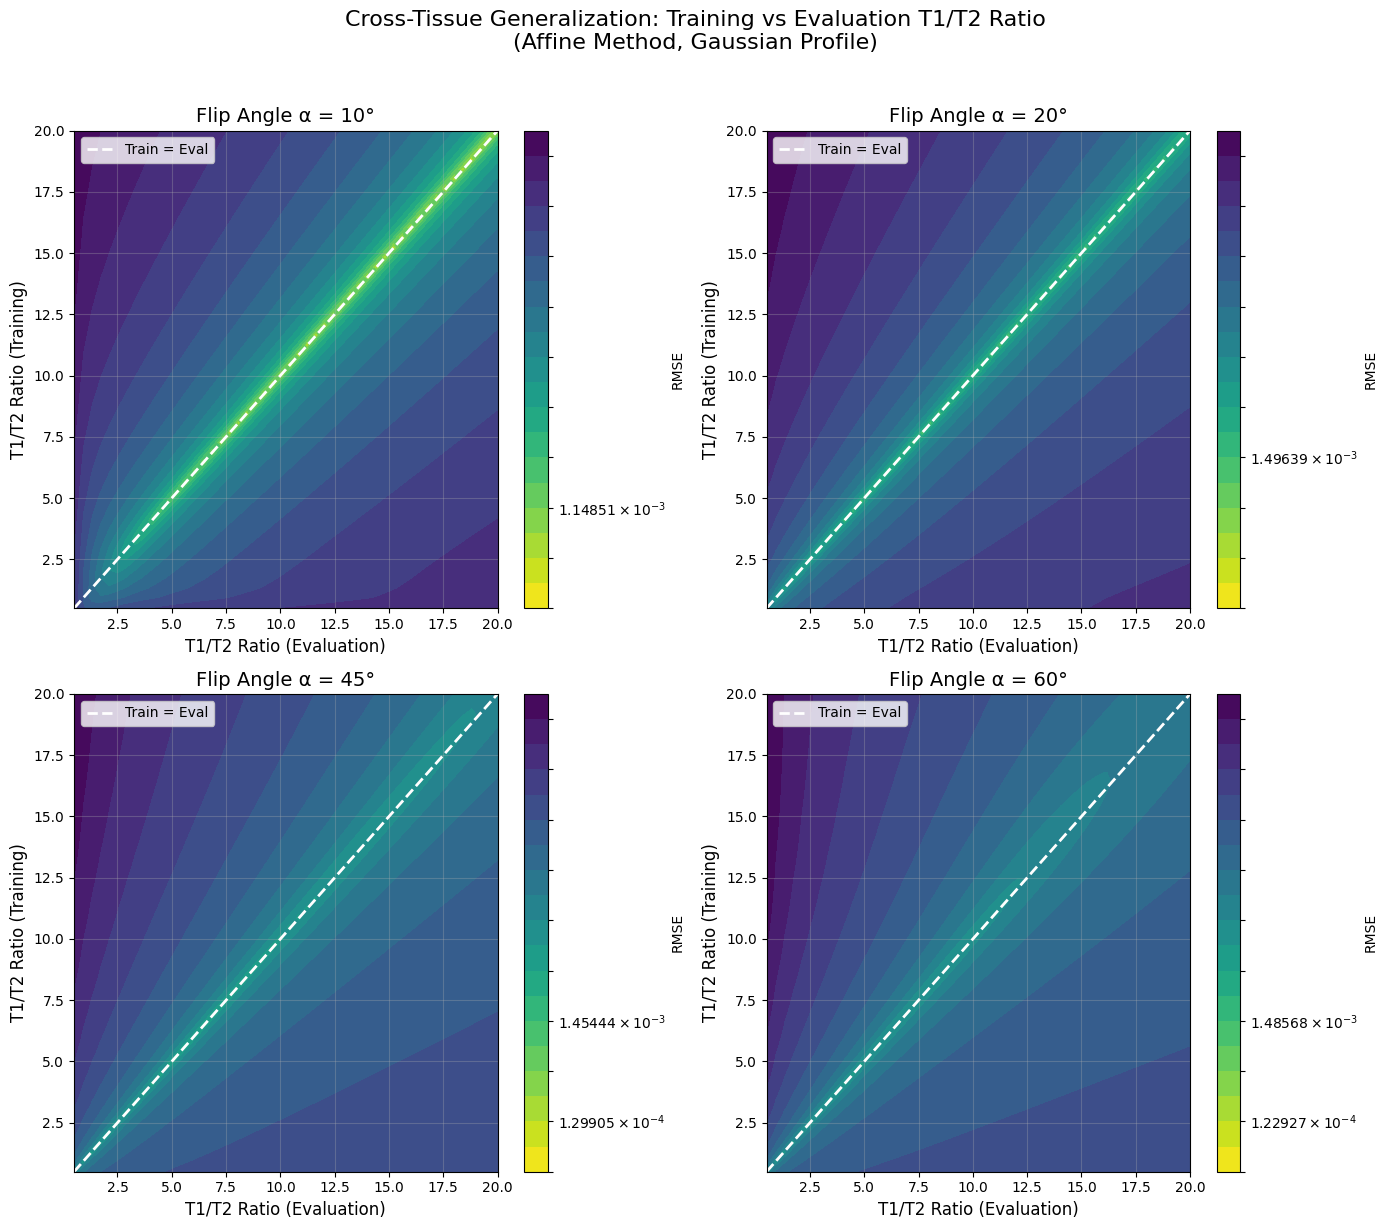

In [12]:
# Plot cross-tissue heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, alpha in enumerate(test_alphas):
    res = results_cross_tissue[alpha]
    plot_heatmap_ratio_vs_ratio(
        res['rmse_2d'], res['ratios'],
        title=f'Flip Angle α = {alpha}°',
        ax=axes[idx],
        cmap='viridis_r'
    )

plt.suptitle('Cross-Tissue Generalization: Training vs Evaluation T1/T2 Ratio\n(Affine Method, Gaussian Profile)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.1 Generalization Metrics by Flip Angle


Generalization Metrics by Flip Angle:
α (deg)      Diag RMSE       Off-Diag RMSE      Gen. Ratio     
----------------------------------------------------------------------
10           0.0038          0.0464             12.15          
20           0.0008          0.1056             139.50         
45           0.0067          0.2743             40.90          
60           0.0171          0.3475             20.37          
----------------------------------------------------------------------

Generalization Ratio = Off-diagonal RMSE / Diagonal RMSE
   Ratio = 1.0: Perfect generalization
   Ratio > 1.0: Degradation when applied to different tissues


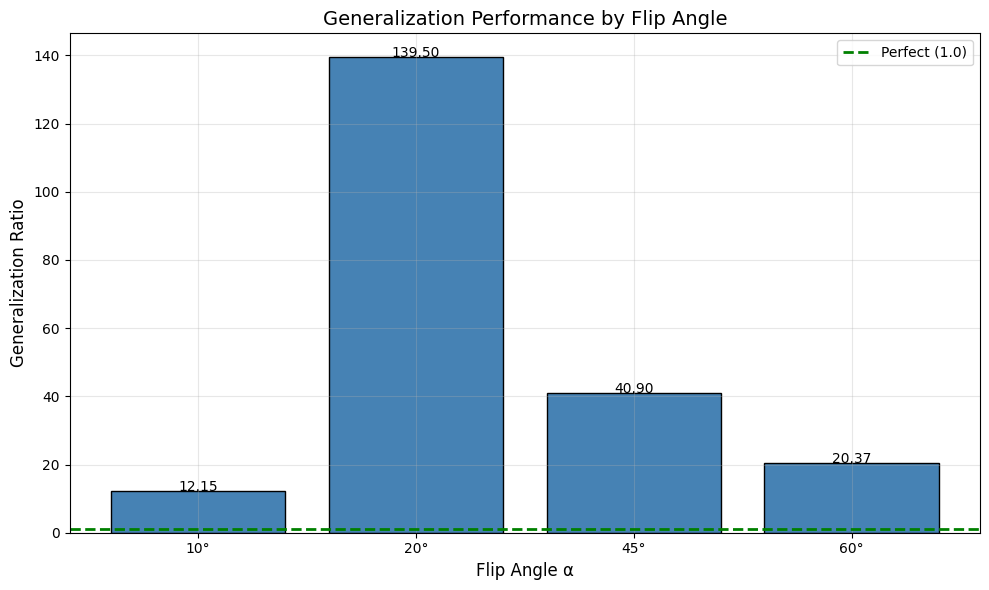

In [13]:
# Compute generalization metrics
print("\nGeneralization Metrics by Flip Angle:")
print("=" * 70)
print(f"{'α (deg)':<12} {'Diag RMSE':<15} {'Off-Diag RMSE':<18} {'Gen. Ratio':<15}")
print("-" * 70)

gen_metrics = []
for alpha in test_alphas:
    rmse_2d = results_cross_tissue[alpha]['rmse_2d']
    mask = ~np.eye(N_RATIO, dtype=bool)
    
    diag_rmse = np.diag(rmse_2d).mean()
    offdiag_rmse = rmse_2d[mask].mean()
    gen_ratio = offdiag_rmse / diag_rmse if diag_rmse > 0 else float('inf')
    
    print(f"{alpha:<12} {diag_rmse:<15.4f} {offdiag_rmse:<18.4f} {gen_ratio:<15.2f}")
    gen_metrics.append((alpha, diag_rmse, offdiag_rmse, gen_ratio))

print("-" * 70)
print("\nGeneralization Ratio = Off-diagonal RMSE / Diagonal RMSE")
print("   Ratio = 1.0: Perfect generalization")
print("   Ratio > 1.0: Degradation when applied to different tissues")

# Plot generalization ratio
fig, ax = plt.subplots(figsize=(10, 6))

alphas_plot = [m[0] for m in gen_metrics]
gen_ratios = [m[3] for m in gen_metrics]

ax.bar(range(len(alphas_plot)), gen_ratios, color='steelblue', edgecolor='black')
ax.axhline(1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
ax.set_xticks(range(len(alphas_plot)))
ax.set_xticklabels([f'{a}°' for a in alphas_plot])
ax.set_xlabel('Flip Angle α', fontsize=12)
ax.set_ylabel('Generalization Ratio', fontsize=12)
ax.set_title('Generalization Performance by Flip Angle', fontsize=14)
ax.legend()

for i, ratio in enumerate(gen_ratios):
    ax.text(i, ratio + 0.02, f'{ratio:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 3. Method Comparison: Cross-Tissue Generalization

In [14]:
# Compare methods for cross-tissue generalization at fixed alpha
FIXED_ALPHA = 20  # degrees

results_method_gen = {}

print(f"Running cross-tissue analysis for all methods at α = {FIXED_ALPHA}°...")
for method in METHODS:
    print(f"  Processing {method}...")
    rmse_2d, ratios = sensitivity_analysis_ratio_vs_ratio(
        D_gaussian,
        alpha=FIXED_ALPHA,
        ratio_min=RATIO_MIN, ratio_max=RATIO_MAX, n_ratio=N_RATIO,
        method=method,
        useL2=True, lam=1e-2
    )
    results_method_gen[method] = {
        'rmse_2d': rmse_2d,
        'ratios': ratios
    }

print("Done!")

Running cross-tissue analysis for all methods at α = 20°...
  Processing linear...
  Processing affine...
  Processing quad...
  Processing quad-cross...
Done!


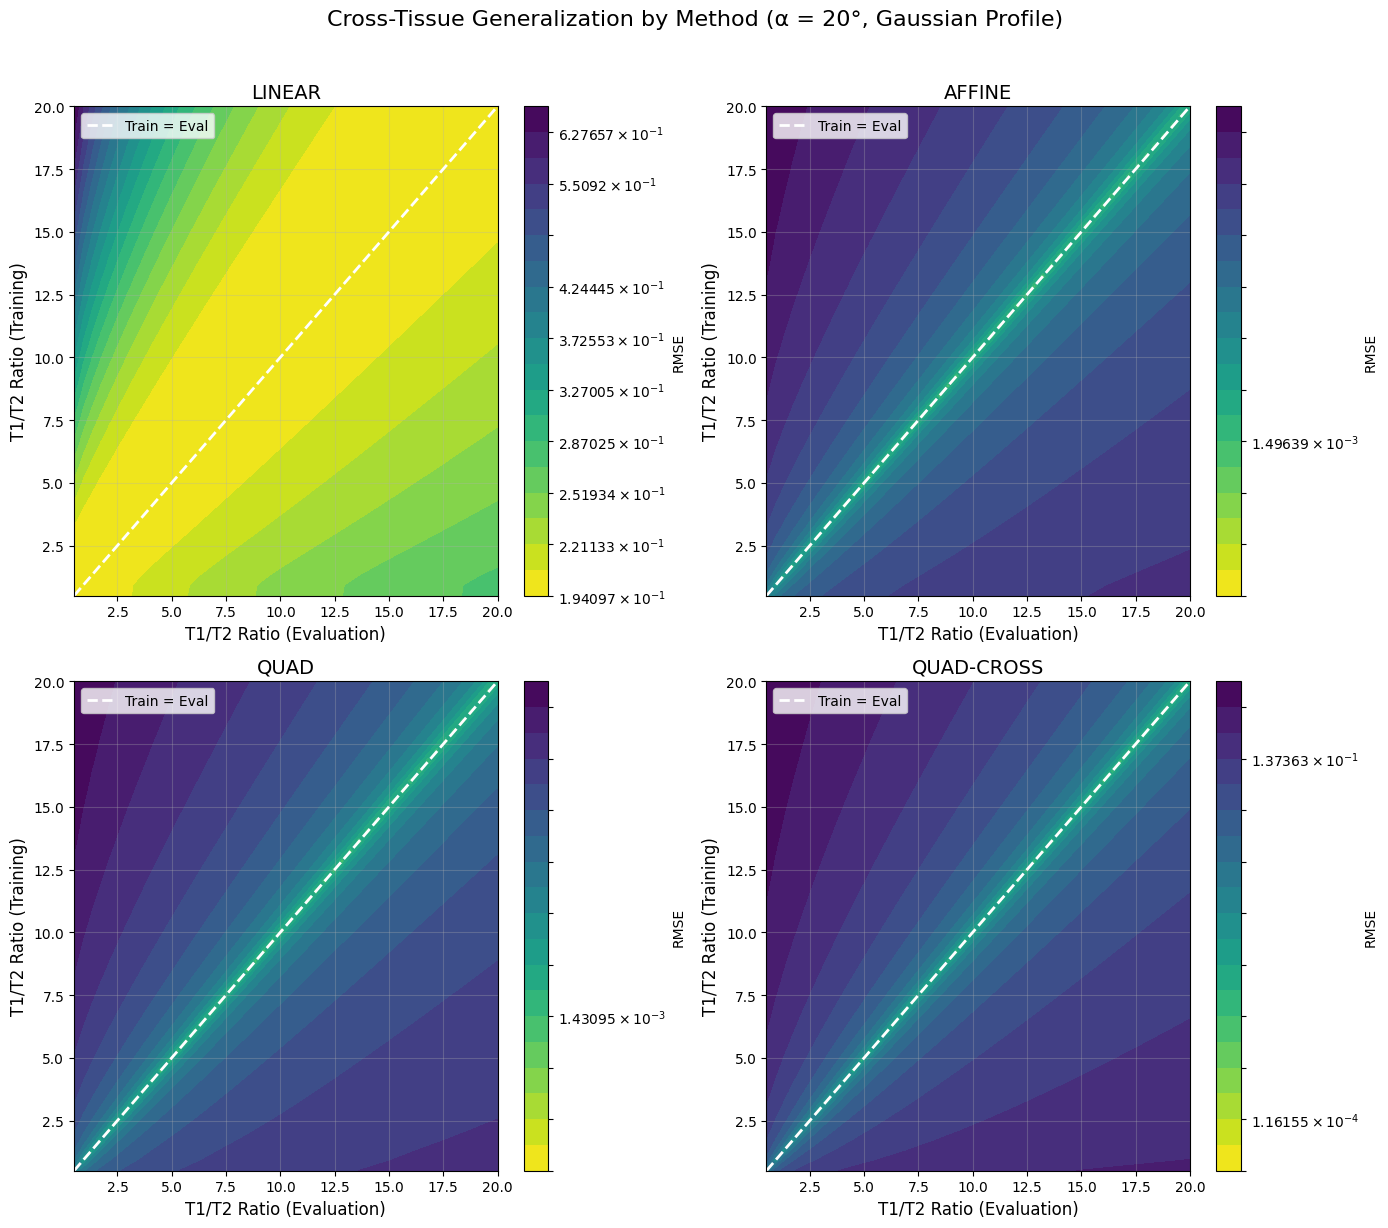

In [15]:
# Plot method comparison heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, method in enumerate(METHODS):
    res = results_method_gen[method]
    plot_heatmap_ratio_vs_ratio(
        res['rmse_2d'], res['ratios'],
        title=f'{method.upper()}',
        ax=axes[idx],
        cmap='viridis_r'
    )

plt.suptitle(f'Cross-Tissue Generalization by Method (α = {FIXED_ALPHA}°, Gaussian Profile)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Method Comparison at α = 20°:
Method          Diag RMSE       Off-Diag RMSE      Gen. Ratio     
----------------------------------------------------------------------
linear          0.1970          0.2322             1.18           
affine          0.0008          0.1056             139.50         
quad            0.0008          0.1059             140.92         
quad-cross      0.0001          0.1180             866.37         


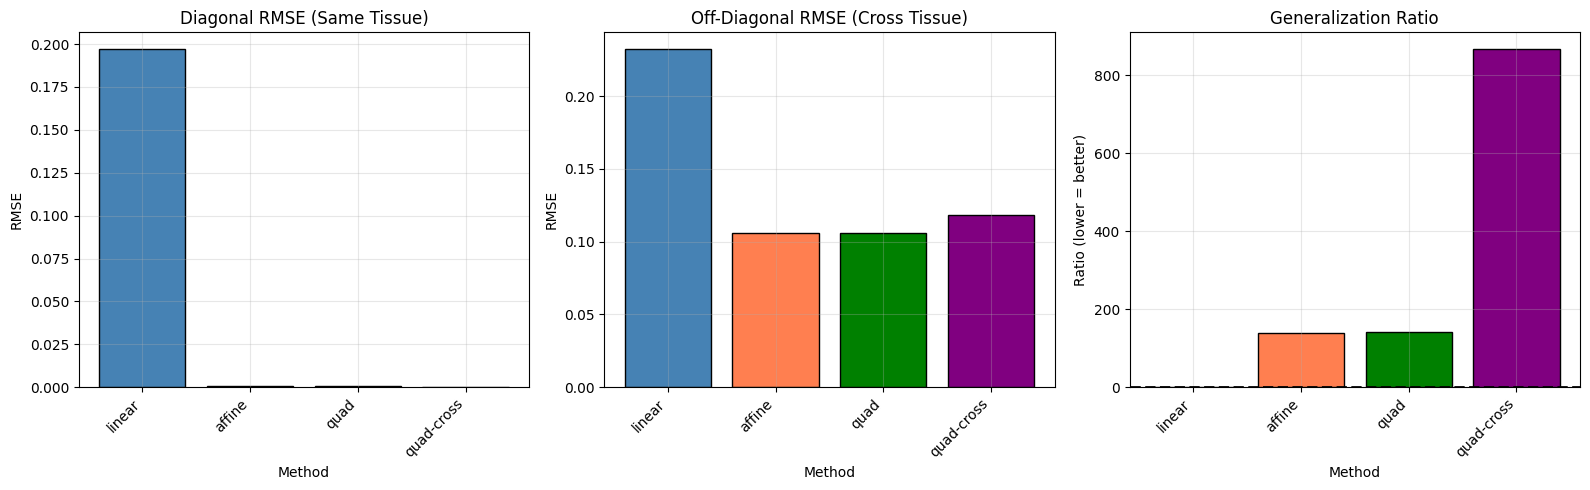

In [16]:
# Summary comparison
print(f"\nMethod Comparison at α = {FIXED_ALPHA}°:")
print("=" * 70)
print(f"{'Method':<15} {'Diag RMSE':<15} {'Off-Diag RMSE':<18} {'Gen. Ratio':<15}")
print("-" * 70)

method_gen_summary = []
for method in METHODS:
    rmse_2d = results_method_gen[method]['rmse_2d']
    mask = ~np.eye(N_RATIO, dtype=bool)
    
    diag_rmse = np.diag(rmse_2d).mean()
    offdiag_rmse = rmse_2d[mask].mean()
    gen_ratio = offdiag_rmse / diag_rmse if diag_rmse > 0 else float('inf')
    
    print(f"{method:<15} {diag_rmse:<15.4f} {offdiag_rmse:<18.4f} {gen_ratio:<15.2f}")
    method_gen_summary.append((method, diag_rmse, offdiag_rmse, gen_ratio))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods_labels = [m[0] for m in method_gen_summary]
diag_values = [m[1] for m in method_gen_summary]
offdiag_values = [m[2] for m in method_gen_summary]
gen_values = [m[3] for m in method_gen_summary]

colors = ['steelblue', 'coral', 'green', 'purple']

axes[0].bar(methods_labels, diag_values, color=colors, edgecolor='black')
axes[0].set_title('Diagonal RMSE (Same Tissue)', fontsize=12)
axes[0].set_ylabel('RMSE')

axes[1].bar(methods_labels, offdiag_values, color=colors, edgecolor='black')
axes[1].set_title('Off-Diagonal RMSE (Cross Tissue)', fontsize=12)
axes[1].set_ylabel('RMSE')

axes[2].bar(methods_labels, gen_values, color=colors, edgecolor='black')
axes[2].axhline(1.0, color='black', linestyle='--', linewidth=2)
axes[2].set_title('Generalization Ratio', fontsize=12)
axes[2].set_ylabel('Ratio (lower = better)')

for ax in axes:
    ax.set_xlabel('Method')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## 4. Training Tissue Comparison

Compare how training on different tissue types affects the sensitivity landscape.

In [17]:
# Compare training on different tissues
training_tissues = {
    'Fat': (0.25, 0.07),
    'Gray Matter': (0.9, 0.1),
    'Muscle': (0.9, 0.05),
}

results_training = {}

print("Running sensitivity analysis for different training tissues...")
for name, (T1, T2) in training_tissues.items():
    print(f"  Training on {name} (T1={T1}, T2={T2})...")
    rmse_2d, rmse_1d, alphas, ratios = sensitivity_analysis_alpha_vs_ratio(
        D_gaussian,
        T1_train=T1, T2_train=T2,
        alpha_min=ALPHA_MIN, alpha_max=ALPHA_MAX, n_alpha=N_ALPHA,
        ratio_min=RATIO_MIN, ratio_max=RATIO_MAX, n_ratio=N_RATIO,
        method='affine',
        useL2=True, lam=1e-2
    )
    results_training[name] = {
        'rmse_2d': rmse_2d,
        'rmse_1d': rmse_1d,
        'alphas': alphas,
        'ratios': ratios,
        'T1': T1,
        'T2': T2
    }

print("Done!")

Running sensitivity analysis for different training tissues...
  Training on Fat (T1=0.25, T2=0.07)...
  Training on Gray Matter (T1=0.9, T2=0.1)...
  Training on Muscle (T1=0.9, T2=0.05)...
Done!


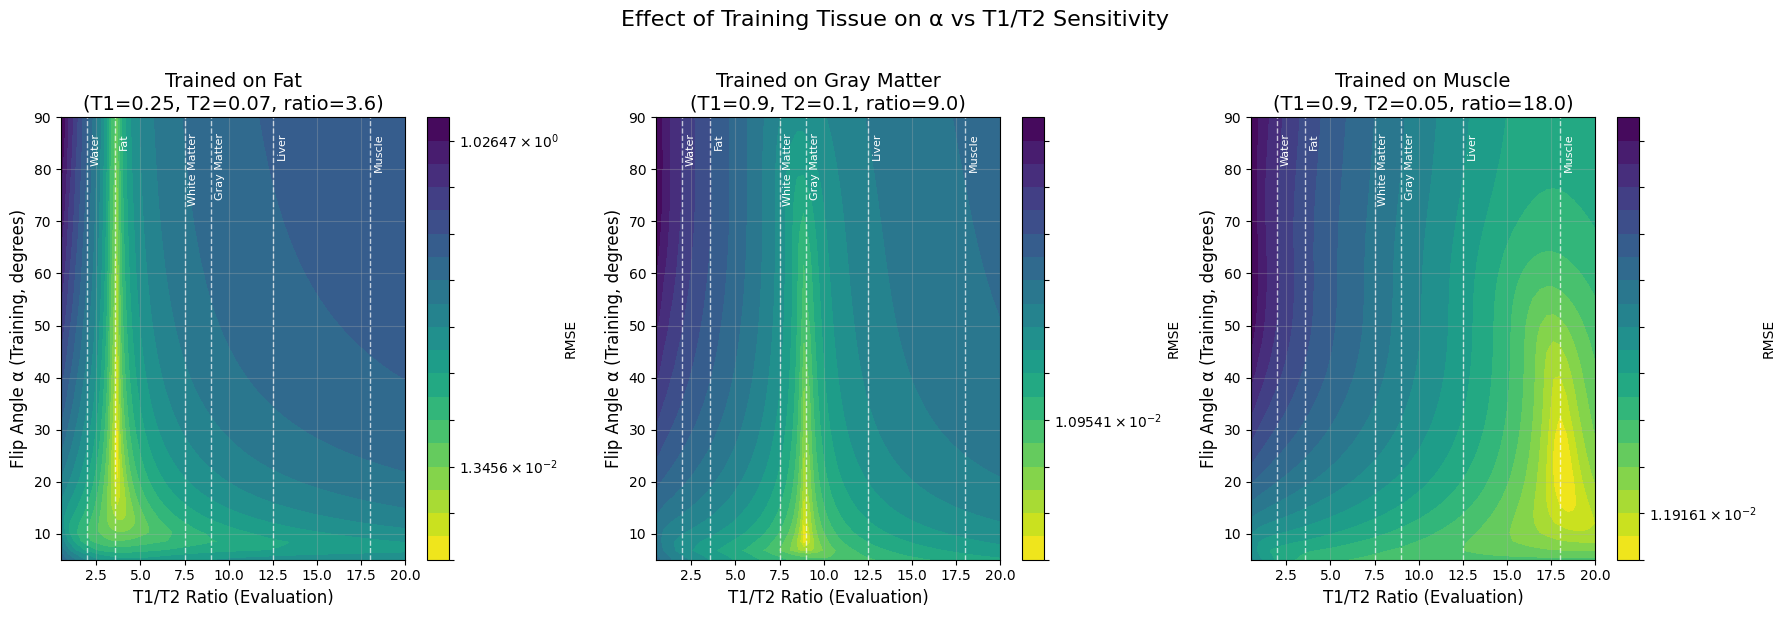

In [18]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, res) in enumerate(results_training.items()):
    plot_heatmap_alpha_vs_ratio(
        res['rmse_2d'], res['alphas'], res['ratios'],
        title=f'Trained on {name}\n(T1={res["T1"]}, T2={res["T2"]}, ratio={res["T1"]/res["T2"]:.1f})',
        ax=axes[idx],
        cmap='viridis_r'
    )

plt.suptitle('Effect of Training Tissue on α vs T1/T2 Sensitivity', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Summary and Recommendations

In [19]:
print("=" * 80)
print("GASP SENSITIVITY ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. FLIP ANGLE SENSITIVITY:")
print("   - Lower flip angles (10-30°) generally provide better generalization")
print("   - Higher flip angles can improve same-tissue performance but reduce generalization")
print("   - Optimal flip angle depends on the target tissue type")

print("\n2. METHOD COMPARISON:")
best_method = min(method_gen_summary, key=lambda x: x[3])
print(f"   - Best generalization: {best_method[0]} (ratio = {best_method[3]:.2f})")
print("   - Simpler methods (linear, affine) tend to generalize better")
print("   - Higher-order methods may overfit to training tissue")

print("\n3. CROSS-TISSUE GENERALIZATION:")
print("   - GASP coefficients do not generalize perfectly across tissues")
print("   - Generalization ratio > 1.0 indicates degradation on different tissues")
print("   - Consider tissue-specific training for critical applications")

print("\n4. TRAINING TISSUE CHOICE:")
print("   - Training on intermediate T1/T2 ratio provides balanced performance")
print("   - Training on extreme ratios may limit generalization range")

print("\n5. RECOMMENDED STARTING PARAMETERS:")
print("   - Method: 'affine' with L2 regularization")
print("   - Flip angle: 15-30° for generalization, 40-60° for specific tissue")
print("   - Training tissue: Match to primary imaging target")
print("   - Profile: Gaussian (most robust)")

print("\n" + "=" * 80)

GASP SENSITIVITY ANALYSIS SUMMARY

1. FLIP ANGLE SENSITIVITY:
   - Lower flip angles (10-30°) generally provide better generalization
   - Higher flip angles can improve same-tissue performance but reduce generalization
   - Optimal flip angle depends on the target tissue type

2. METHOD COMPARISON:
   - Best generalization: linear (ratio = 1.18)
   - Simpler methods (linear, affine) tend to generalize better
   - Higher-order methods may overfit to training tissue

3. CROSS-TISSUE GENERALIZATION:
   - GASP coefficients do not generalize perfectly across tissues
   - Generalization ratio > 1.0 indicates degradation on different tissues
   - Consider tissue-specific training for critical applications

4. TRAINING TISSUE CHOICE:
   - Training on intermediate T1/T2 ratio provides balanced performance
   - Training on extreme ratios may limit generalization range

5. RECOMMENDED STARTING PARAMETERS:
   - Method: 'affine' with L2 regularization
   - Flip angle: 15-30° for generalization, 40